### Neural Network Classification Exercise

Yumol, Dianne

In [1]:

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
import random
import os

In [2]:
# Load the CSV file
df = pd.read_csv("https://happy-research.s3.ap-southeast-1.amazonaws.com/pageblocks.csv", header=None)

# Rename columns to x1 ... xn and y
num_features = df.shape[1] - 1
column_names = [f"x{i+1}" for i in range(num_features)] + ["y"]
df.columns = column_names

# Convert all -1 in 'y' to 0, retain 1 as 1
df['y'] = df['y'].apply(lambda val: 0 if val == -1 else val)

# Display the first few rows of the modified DataFrame
df

,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10,y
0,0.002491,0.105072,0.001181,0.036611,0.446203,0.440299,0.016754,0.002333,0.001669,0.000000,0
1,0.001245,0.034420,0.000229,0.018609,0.657173,0.653518,0.005248,0.000606,0.000434,0.000000,0
2,0.001245,0.030797,0.000201,0.016747,0.648734,0.673774,0.004643,0.000515,0.000390,0.000000,0
3,0.000000,0.016304,0.000021,0.018609,1.000000,1.000000,0.001817,0.000091,0.000065,0.000000,0
4,0.000000,0.021739,0.000042,0.024196,1.000000,1.000000,0.002422,0.000182,0.000130,0.000000,0
...,...,...,...,...,...,...,...,...,...,...,...
5383,0.012453,0.264493,0.011182,0.024874,0.216245,0.745203,0.000117,0.012390,0.026514,0.081906,1
5384,0.012453,0.347826,0.014696,0.032660,0.201477,0.662047,0.000119,0.015420,0.031306,0.100903,1
5385,0.007472,0.005435,0.000146,0.001050,0.698312,0.924307,0.001817,0.000394,0.000412,0.000311,1
5386,0.006227,0.170290,0.003910,0.029472,0.261603,0.905117,0.000129,0.004968,0.011100,0.032077,1


In [3]:
# Split the dataset into training and testing sets
df_train, df_test = train_test_split(df, test_size=0.2, random_state=42)

# Display the sizes of the partitions
print(f"Training set size: {df_train.shape[0]} rows")
print(f"Testing set size: {df_test.shape[0]} rows")

Training set size: 4310 rows
Testing set size: 1078 rows


In [19]:
# Ensure features are floats and labels are ints 0/1
X_train = df_train.drop(columns=['y']).values.astype(np.float32)
X_test  = df_test.drop(columns=['y']).values.astype(np.float32)
y_train = df_train['y'].values.astype(np.int64)
y_test  = df_test['y'].values.astype(np.int64)

# Standardize features
#scaler = StandardScaler()
#X_train = scaler.fit_transform(X_train)
#X_test  = scaler.transform(X_test)

batch_size = 32
train_ds = TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train))
test_ds  = TensorDataset(torch.from_numpy(X_test), torch.from_numpy(y_test))
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

input_dim = X_train.shape[1]  # should match number of features (10)

In [20]:
# Question 1: Plain 5-layer feedforward network
class MLPPlain(nn.Module):
    def __init__(self, input_dim=10):
        super().__init__()
        self.l1 = nn.Linear(input_dim, 64)
        self.l2 = nn.Linear(64, 128)
        self.l3 = nn.Linear(128, 64)
        self.l4 = nn.Linear(64, 32)
        self.out = nn.Linear(32, 2)   # logits for CrossEntropyLoss
        self.act = nn.ReLU()
    def forward(self, x):
        x = self.act(self.l1(x))
        x = self.act(self.l2(x))
        x = self.act(self.l3(x))
        x = self.act(self.l4(x))
        x = self.out(x)
        return x

In [21]:
# Question 2: Residual network (same layers, plus residuals)
class MLPRes(nn.Module):
    def __init__(self, input_dim=10):
        super().__init__()
        self.l1 = nn.Linear(input_dim, 64)
        self.l2 = nn.Linear(64, 128)
        self.l3 = nn.Linear(128, 64)
        self.l4 = nn.Linear(64, 32)
        self.out = nn.Linear(32, 2)
        self.act = nn.ReLU()
        # projection from l2 (128) -> l4 (32) so we can add them
        self.proj_l2_to_l4 = nn.Linear(128, 32)
    def forward(self, x):
        out1 = self.act(self.l1(x))        # 64
        out2 = self.act(self.l2(out1))     # 128
        out3 = self.l3(out2)               # 64 (pre-act)
        # residual: add output of L1 (64) to L3 (64)
        out3 = self.act(out3 + out1)
        out4 = self.l4(out3)               # 32 (pre-act)
        # residual: project L2 (128) -> 32 and add to L4 (32)
        proj = self.proj_l2_to_l4(out2)
        out4 = self.act(out4 + proj)
        logits = self.out(out4)
        return logits



In [ ]:
# Training
def train_epoch(model, loader, optimizer, loss_fn):
    model.train()
    total_loss = 0.0
    for xb, yb in loader:
        optimizer.zero_grad()
        logits = model(xb)
        loss = loss_fn(logits, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * xb.size(0)
    return total_loss / len(loader.dataset)

def evaluate_on_loader(model, loader, loss_fn=None):
    model.eval()
    preds = []
    labels = []
    total_loss = 0.0
    with torch.no_grad():
        for xb, yb in loader:
            logits = model(xb)
            if loss_fn is not None:
                total_loss += loss_fn(logits, yb).item() * xb.size(0)
            p = torch.argmax(logits, dim=1).cpu().numpy()
            preds.append(p)
            labels.append(yb.cpu().numpy())
    preds = np.concatenate(preds)
    labels = np.concatenate(labels)
    avg_loss = (total_loss / len(loader.dataset)) if loss_fn is not None else None
    return preds, labels, avg_loss

def metrics_from_preds(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    return {"accuracy": acc, "precision": prec, "recall": rec, "f1": f1}

# Training loop to collect losses
def fit_model(model, train_loader, test_loader, epochs=60, lr=1e-3):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()
    train_losses = []
    test_losses = []
    for ep in range(1, epochs+1):
        tr_loss = train_epoch(model, train_loader, optimizer, loss_fn)
        _, _, te_loss = evaluate_on_loader(model, test_loader, loss_fn=loss_fn)
        train_losses.append(tr_loss)
        test_losses.append(te_loss)
        if ep == 1 or ep % 10 == 0:
            print(f"Epoch {ep:03d} | train_loss={tr_loss:.4f} | test_loss={te_loss:.4f}")
    return model, train_losses, test_losses



In [33]:
# Instantiate and train both models
epochs = 100
plain_model = MLPPlain(input_dim=input_dim)
res_model   = MLPRes(input_dim=input_dim)

print("\nTraining plain MLP...")
plain_trained, plain_tr_losses, plain_te_losses = fit_model(plain_model, train_loader, test_loader, epochs=epochs, lr=1e-3)

print("\nTraining residual MLP...")
res_trained, res_tr_losses, res_te_losses = fit_model(res_model, train_loader, test_loader, epochs=epochs, lr=1e-3)

plain_preds, plain_labels, _ = evaluate_on_loader(plain_trained, test_loader)
res_preds,   res_labels,   _ = evaluate_on_loader(res_trained, test_loader)

plain_metrics = metrics_from_preds(plain_labels, plain_preds)
res_metrics   = metrics_from_preds(res_labels, res_preds)

print("\nFinal Test Metrics")
print("Plain MLP:")
for k,v in plain_metrics.items(): print(f"  {k}: {v:.4f}")
print("\nResidual MLP:")
for k,v in res_metrics.items(): print(f"  {k}: {v:.4f}")

print("\nClassification report - Plain MLP:\n")
print(classification_report(plain_labels, plain_preds, digits=4))
print("Classification report - Residual MLP:\n")
print(classification_report(res_labels, res_preds, digits=4))


Training plain MLP...
Epoch 001 | train_loss=0.3241 | test_loss=0.2232
Epoch 010 | train_loss=0.1035 | test_loss=0.1221
Epoch 020 | train_loss=0.0844 | test_loss=0.0883
Epoch 030 | train_loss=0.0731 | test_loss=0.0740
Epoch 040 | train_loss=0.0665 | test_loss=0.0788
Epoch 050 | train_loss=0.0657 | test_loss=0.0714
Epoch 060 | train_loss=0.0621 | test_loss=0.0732
Epoch 070 | train_loss=0.0623 | test_loss=0.0770
Epoch 080 | train_loss=0.0557 | test_loss=0.0831
Epoch 090 | train_loss=0.0551 | test_loss=0.0940
Epoch 100 | train_loss=0.0522 | test_loss=0.0971

Training residual MLP...
Epoch 001 | train_loss=0.3023 | test_loss=0.2000
Epoch 010 | train_loss=0.1044 | test_loss=0.1301
Epoch 020 | train_loss=0.0804 | test_loss=0.0777
Epoch 030 | train_loss=0.0748 | test_loss=0.0746
Epoch 040 | train_loss=0.0674 | test_loss=0.0718
Epoch 050 | train_loss=0.0632 | test_loss=0.0835
Epoch 060 | train_loss=0.0601 | test_loss=0.0679
Epoch 070 | train_loss=0.0561 | test_loss=0.0821
Epoch 080 | train_lo

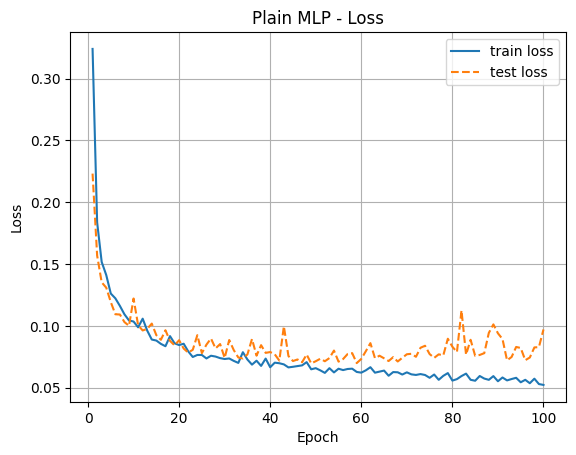

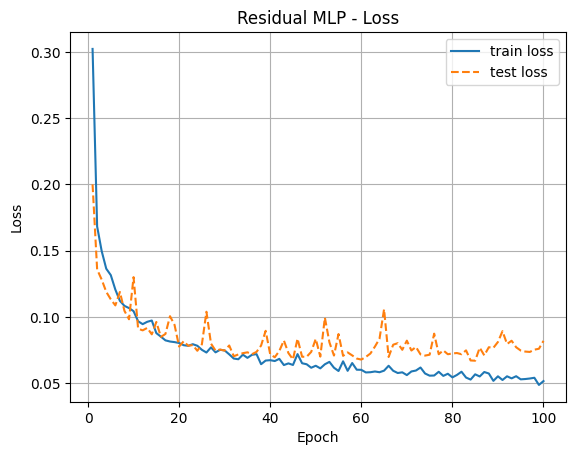

In [34]:
# Plot training loss curves
plt.figure()
plt.plot(np.arange(1, epochs+1), plain_tr_losses, label="train loss")
plt.plot(np.arange(1, epochs+1), plain_te_losses, label="test loss", linestyle="--")
plt.title("Plain MLP - Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()
plt.show()

plt.figure()
plt.plot(np.arange(1, epochs+1), res_tr_losses, label="train loss")
plt.plot(np.arange(1, epochs+1), res_te_losses, label="test loss", linestyle="--")
plt.title("Residual MLP - Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()
plt.show()

## Guide Questions

## Performance Comparison

### Which model achieved better test accuracy and F1-score?
Both models achieved identical test accuracy (97.40%), but there are subtle differences in their performance characteristics.

The plain MLP achieved an F1-score of 0.9856, with higher recall (0.9927) but lower precision (0.9785). The residual MLP obtaine an F1-score of 0.9855, with more balanced precision (0.9865) and recall (0.9845). The performance difference is marginal, with the plain MLP having a slight edge in F1-score by 0.0001.

### Did residual connections improve generalization?
The residual model demonstrated more consistent test loss behavior, with less dramatic increases in later epochs. However, both models achieved identical final accuracy, suggesting similar generalization capabilities. The residual model showed better balance between precision and recall, which could indicate more robust decision boundaries.

## Training Behavior

### Which model converged faster?
The residual MLP converged slightly faster. As seen on epoch 1, the residual started with lower loss (0.3023 vs 0.3241 train, 0.2000 vs 0.2232 test). However, both models reached similar performance levels around epoch 30-40. The residual model maintained more stable training throughout.

### Were there differences in training loss curves?
Yes, notable differences include how the residual MLP is more consistent descent with fewer fluctuations in test loss while the plain MLP showed more erratic test loss behavior, particularly in later epochs (dramatic increase from 0.0714 at epoch 50 to 0.0971 at epoch 100). The residual model's test loss remained more stable throughout training, suggesting better optimization dynamics.

## Architectural Impact

### How did residuals affect the model’s ability to learn deeper representations?
The residual connections provided several benefits. It enabled more direct gradient paths, reducing vanishing gradient issues and skip connections allowed earlier layer features to be preserved and combined with deeper representations. Finally, there were more consistent loss curves, which indicate smoother optimization landscape.

### Did the residual model show signs of better gradient flow?
Yes, some evidence includes faster initial convergence, more stable training dynamics (less erratic test loss) and consistent improvement without the dramatic loss increases seen in the plain MLP.

## Practical Considerations

### Would you recommend using residuals for similar datasets?

For this specific scenario, the recommendation is conditionally yes. In this case, the residual MLP had better training stability and consistency, faster convergence, more balanced precision-recall trade-off, and protection against optimization difficulties.

In general cases, however, it depends on the  objective metric. If our main focus is accuracy/weighted F1 on this dataset, then residuals are not necessary (both models tie). If we care about balanced performance across classes or specifically want to raise recall on the minority class (catch more positives for class 0), residuals can help (they raised recall for class 0 from 0.8142 to 0.8850 here).

### What trade-offs did you observe in complexity vs. performance?

For the case of complexity,  the residual model adds parameters (and the projection layer), slightly higher compute and implementation complexity. There was a slight increase in forward pass operations and minor increase due to storing intermediate activations.

On the other hand, for performance, no gain in overall accuracy/F1, but a meaningful class-balance benefit: better minority-class recall at the cost of lower minority-class precision. For imbalanced problems, this tradeoff is often desirable.